# 1.**Preprocessing**

In [1]:
# ==========================================
# Cell 1: Install & Import Libraries
# ==========================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import random
from google.colab import drive

In [2]:
# ==========================================
# Cell 2: Mount Google Drive
# ==========================================
drive.mount('/content/drive')

AWAKE_PATH  = "/content/drive/MyDrive/train/awake"
DROWSY_PATH = "/content/drive/MyDrive/train/drowsy"

print(f"Awake  images: {len(glob.glob(AWAKE_PATH  + '/*'))}")
print(f"Drowsy images: {len(glob.glob(DROWSY_PATH + '/*'))}")

Mounted at /content/drive
Awake  images: 2713
Drowsy images: 3916



  Class Balance — Raw Images (Train)
  Total Images       : 6629
  Awake  (0)         :  2713  (40.9%)
  Drowsy (1)         :  3916  (59.1%)
  Awake/Drowsy Ratio : 0.69
  ⚠️  Slight imbalance — فكر في class_weight عند التدريب


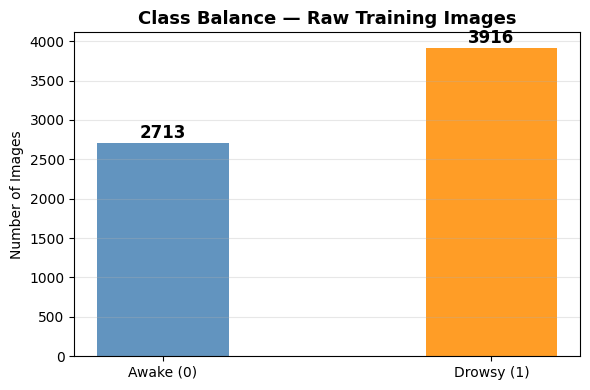

Saved → class_balance_raw.png


In [4]:
# ==========================================
# Cell 3: Class Balance Check (Raw Data)
# ==========================================
import glob

def check_class_balance_raw(awake_path, drowsy_path):
    extensions = ["/*.jpg", "/*.jpeg", "/*.png"]

    n_awake  = sum(len(glob.glob(awake_path  + ext)) for ext in extensions)
    n_drowsy = sum(len(glob.glob(drowsy_path + ext)) for ext in extensions)
    total    = n_awake + n_drowsy
    ratio    = n_awake / n_drowsy if n_drowsy > 0 else float('inf')

    print(f"\n{'='*45}")
    print(f"  Class Balance — Raw Images (Train)")
    print(f"{'='*45}")
    print(f"  Total Images       : {total}")
    print(f"  Awake  (0)         : {n_awake:>5}  ({n_awake/total*100:.1f}%)")
    print(f"  Drowsy (1)         : {n_drowsy:>5}  ({n_drowsy/total*100:.1f}%)")
    print(f"  Awake/Drowsy Ratio : {ratio:.2f}")

    if 0.8 <= ratio <= 1.25:
        print("  ✅ Balanced — لا تحتاج أي تعديل")
    elif 0.5 <= ratio < 0.8 or 1.25 < ratio <= 2.0:
        print("  ⚠️  Slight imbalance — فكر في class_weight عند التدريب")
    else:
        print("  ❌ Significant imbalance — استخدم oversampling أو class_weight!")
    print(f"{'='*45}")

    return n_awake, n_drowsy

n_awake, n_drowsy = check_class_balance_raw(AWAKE_PATH, DROWSY_PATH)

# ── Bar Chart ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Awake (0)", "Drowsy (1)"],
              [n_awake, n_drowsy],
              color=["steelblue", "darkorange"],
              alpha=0.85, width=0.4)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 5,
            str(h), ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_title("Class Balance — Raw Training Images", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Images")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("class_balance_raw.png", dpi=150)
plt.show()
print("Saved → class_balance_raw.png")


In [5]:
# ==========================================
# Cell 3: Preprocessing Function
# ==========================================
def preprocess(img_path):
    # 1. Read Image
    img = cv2.imread(img_path)
    if img is None:
        return None, None

    # 2. Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3. Resize
    resized = cv2.resize(gray, (64, 64))

    # 4. Normalize
    normalized = resized.astype("float32") / 255.0

    original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return original, normalized

In [6]:
# ==========================================
# Cell 4: Load All Images + Augment Awake
# ==========================================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def load_images(folder, label):
    X, y = [], []

    files = glob.glob(folder + "/*.jpg") + \
            glob.glob(folder + "/*.jpeg") + \
            glob.glob(folder + "/*.png")

    for path in files:
        original, processed = preprocess(path)
        if processed is not None:
            X.append(processed)
            y.append(label)

    print(f"Loaded: {len(X)} / {len(files)}  →  label={label}")
    return X, y


X_awake,  y_awake  = load_images(AWAKE_PATH,  label=0)
X_drowsy, y_drowsy = load_images(DROWSY_PATH, label=1)

# ── Augment Awake only to match Drowsy count ──────────────────────
target   = len(X_drowsy)
shortage = target - len(X_awake)

print(f"\nAwake  before aug : {len(X_awake)}")
print(f"Drowsy            : {len(X_drowsy)}")
print(f"Need to generate  : {shortage} extra Awake images")

aug = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

X_awake_arr = np.array(X_awake).reshape(-1, 64, 64, 1)
aug_gen     = aug.flow(X_awake_arr,
                       np.zeros(len(X_awake_arr)),
                       batch_size=32,
                       shuffle=True)

X_aug, y_aug = [], []
generated    = 0

while generated < shortage:
    batch_X, _ = next(aug_gen)
    for img in batch_X:
        if generated >= shortage:
            break
        X_aug.append(img.reshape(64, 64))
        y_aug.append(0)
        generated += 1

print(f"Generated         : {len(X_aug)} augmented Awake images")

# ── Combine everything ────────────────────────────────────────────
X = np.array(X_awake + X_drowsy + X_aug)
y = np.array(y_awake + y_drowsy + y_aug)

print(f"\nAfter Balancing:")
print(f"  Awake  (0) : {int((y == 0).sum())}")
print(f"  Drowsy (1) : {int((y == 1).sum())}")
print(f"  Total      : {len(X)} samples | Shape: {X.shape}")


Loaded: 2713 / 2713  →  label=0
Loaded: 3916 / 3916  →  label=1

Awake  before aug : 2713
Drowsy            : 3916
Need to generate  : 1203 extra Awake images
Generated         : 1203 augmented Awake images

After Balancing:
  Awake  (0) : 3916
  Drowsy (1) : 3916
  Total      : 7832 samples | Shape: (7832, 64, 64)


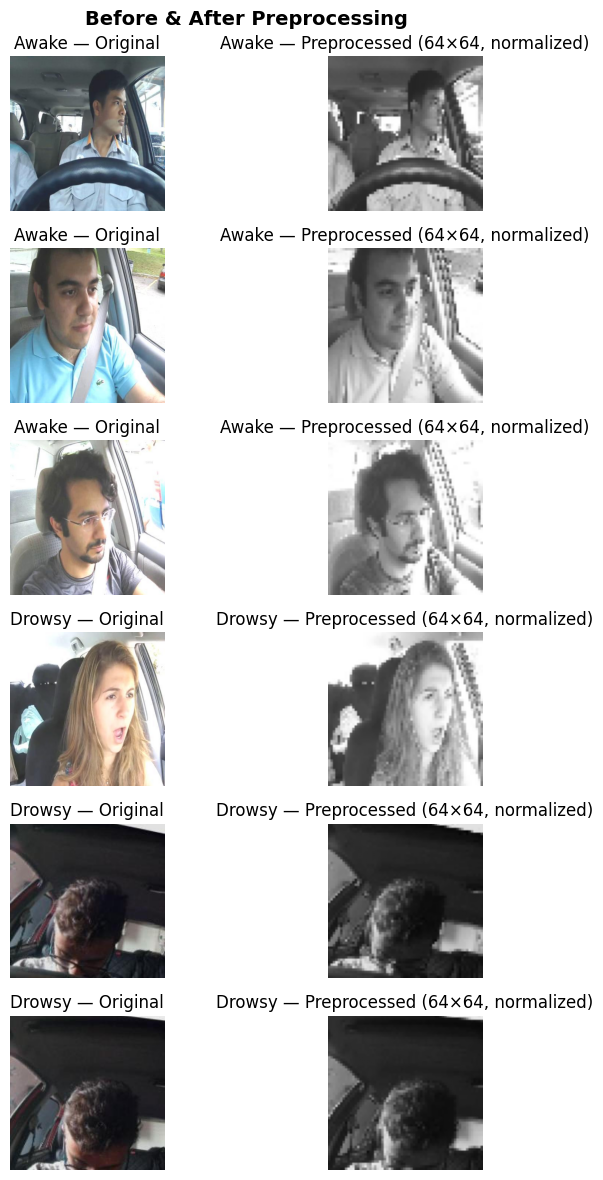

Saved → preview.png


In [7]:
# ==========================================
# Cell 5: Show Before & After Samples
# ==========================================
def show_samples(awake_folder, drowsy_folder, n=3):

    awake_files  = random.sample(glob.glob(awake_folder  + "/*.jpg"), n)
    drowsy_files = random.sample(glob.glob(drowsy_folder + "/*.jpg"), n)

    fig, axes = plt.subplots(n * 2, 2, figsize=(8, n * 4))
    fig.suptitle("Before & After Preprocessing", fontsize=14, fontweight="bold")

    all_files  = awake_files + drowsy_files
    all_labels = ["Awake"] * n + ["Drowsy"] * n

    for i, (path, label) in enumerate(zip(all_files, all_labels)):
        original, processed = preprocess(path)

        # Before
        axes[i][0].imshow(original)
        axes[i][0].set_title(f"{label} — Original")
        axes[i][0].axis("off")

        # After
        axes[i][1].imshow(processed, cmap="gray", vmin=0, vmax=1)
        axes[i][1].set_title(f"{label} — Preprocessed (64×64, normalized)")
        axes[i][1].axis("off")

    plt.tight_layout()
    plt.savefig("preview.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → preview.png")


show_samples(AWAKE_PATH, DROWSY_PATH, n=3)

In [8]:
# ==========================================
# Cell 6: Save Dataset
# ==========================================
save_path = "/content/drive/MyDrive/train/dataset.npz"

np.savez_compressed(save_path, X=X, y=y)

print(f"Saved → {save_path}")
print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : 0=Awake | 1=Drowsy")

Saved → /content/drive/MyDrive/train/dataset.npz
X shape : (7832, 64, 64)
y shape : (7832,)
Classes : 0=Awake | 1=Drowsy


#2. **Neural Net implementation**

In [10]:
# ==========================================
# Cell: Import Keras & TensorFlow
# ==========================================
import tensorflow as tf
from tensorflow.keras import layers, models

In [11]:
random.seed(0)

model = models.Sequential()

# Block 1
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)))
model.add(layers.MaxPooling2D((2, 2)))

# Block 2
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Block 3
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))      # ← يمنع overfitting

model.add(layers.Dense(1, activation='sigmoid'))  # ← binary output

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 350,913 (1.34 MB)

 Trainable params: 350,913 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==========================================
# Cell: Load Saved Datasets
# ==========================================
train_data = np.load("/content/drive/MyDrive/train/dataset.npz")
val_data   = np.load("/content/drive/MyDrive/valid/dataset.npz")
test_data  = np.load("/content/drive/MyDrive/test/dataset.npz")

X_train, y_train = train_data['X'].reshape(-1, 64, 64, 1), train_data['y']
X_val,   y_val   = val_data['X'].reshape(-1, 64, 64, 1),   val_data['y']
X_test,  y_test  = test_data['X'].reshape(-1, 64, 64, 1),  test_data['y']

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

# ==========================================
# Cell: Train + Augmentation
# ==========================================
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=100,
    validation_data=(X_val, y_val)
)

# ── Save History ──────────────────────────────────────────────────
import json

history_path = "/content/drive/MyDrive/project_image_cnn_from_scratch/history.json"

with open(history_path, "w") as f:
    json.dump(history.history, f)

print(f"History Saved → {history_path}")

Train : (7832, 64, 64, 1)
Val   : (1890, 64, 64, 1)
Test  : (948, 64, 64, 1)
Epoch 1/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8717 - loss: 0.3044 - val_accuracy: 0.7968 - val_loss: 0.4537
Epoch 2/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8793 - loss: 0.2918 - val_accuracy: 0.8471 - val_loss: 0.3446
Epoch 3/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8864 - loss: 0.2786 - val_accuracy: 0.8582 - val_loss: 0.3173
Epoch 4/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.8874 - loss: 0.2764 - val_accuracy: 0.8529 - val_loss: 0.3429
Epoch 5/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8953 - loss: 0.2673 - val_accuracy: 0.8582 - val_loss: 0.3139
Epoch 6/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8979 - loss: 0.2566 - val_accuracy: 0.8354 - val_loss: 0.3747
Epoch 7/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8972 - loss: 0.2561 - val_accuracy: 0.8582 - val_loss: 0.3252
Epoch 8/100
2

In [14]:
# ==========================================
# Cell: Evaluate on Test Set
# ==========================================
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy * 100:.2f}%")

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8987 - loss: 0.3272
Test Loss     : 0.3272
Test Accuracy : 89.87%


In [15]:
# ==========================================
# Cell: Save Model
# ==========================================
model.save("/content/drive/MyDrive/project_image_cnn_from_scratch/drowsiness_model.keras")
print("Model Saved!")

Model Saved!


In [16]:
# ==========================================
# Cell: Reload Test Data
# ==========================================
import numpy as np

test_data = np.load("/content/drive/MyDrive/test/dataset.npz")
X_test, y_test = test_data['X'].reshape(-1, 64, 64, 1), test_data['y']

print(f"Test : {X_test.shape}")

Test : (948, 64, 64, 1)


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
  Accuracy  : 89.87%
  Precision : 88.87%
  Recall    : 94.61%
  F1-Score  : 91.65%

Detailed Classification Report:
              precision    recall  f1-score   support

   Awake (0)       0.92      0.83      0.87       391
  Drowsy (1)       0.89      0.95      0.92       557

    accuracy                           0.90       948
   macro avg       0.90      0.89      0.89       948
weighted avg       0.90      0.90      0.90       948



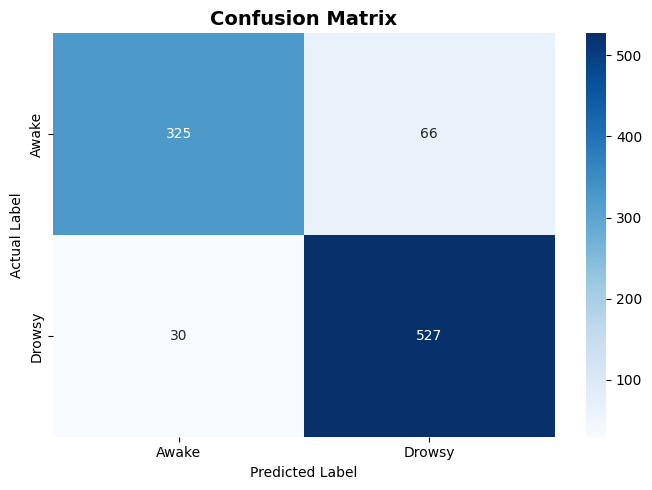

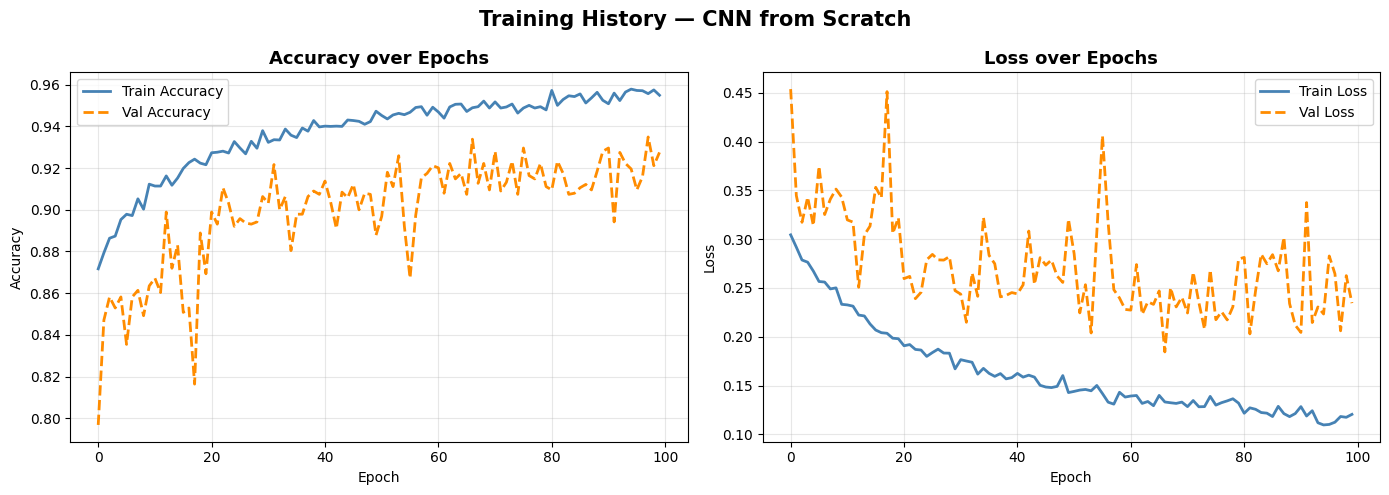

In [17]:
# ==========================================
# Cell: Full Evaluation — Binary Classification
# ==========================================
from tensorflow.keras.models import load_model
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc,
                              classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── 1. Load Model & Data ──────────────────────────────────────────
model     = load_model("/content/drive/MyDrive/project_image_cnn_from_scratch/drowsiness_model.keras")

test_data = np.load("/content/drive/MyDrive/test/dataset.npz")
X_test    = test_data['X'].reshape(-1, 64, 64, 1)
y_test    = test_data['y']

# ── 2. Predict ────────────────────────────────────────────────────
y_pred_prob = model.predict(X_test).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)
y_true      = y_test.flatten()

# ── 3. Metrics ────────────────────────────────────────────────────
acc  = accuracy_score (y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score   (y_true, y_pred, zero_division=0)
f1   = f1_score       (y_true, y_pred, zero_division=0)

print("=" * 45)
print(f"  Accuracy  : {acc  * 100:.2f}%")
print(f"  Precision : {prec * 100:.2f}%")
print(f"  Recall    : {rec  * 100:.2f}%")
print(f"  F1-Score  : {f1   * 100:.2f}%")
print("=" * 45)
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred,
                             target_names=['Awake (0)', 'Drowsy (1)'],
                             zero_division=0))

# ── 4. Confusion Matrix ───────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Awake', 'Drowsy'],
            yticklabels=['Awake', 'Drowsy'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# ── 6. Loss & Accuracy Curves (من الـ history المحفوظ) ───────────
import json

with open("/content/drive/MyDrive/project_image_cnn_from_scratch/history.json") as f:
    hist = json.load(f)

train_acc  = hist['accuracy']
val_acc    = hist['val_accuracy']
train_loss = hist['loss']
val_loss   = hist['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_acc, label='Train Accuracy', color='steelblue',  lw=2)
axes[0].plot(val_acc,   label='Val Accuracy',   color='darkorange', lw=2, linestyle='--')
axes[0].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(train_loss, label='Train Loss', color='steelblue',  lw=2)
axes[1].plot(val_loss,   label='Val Loss',   color='darkorange', lw=2, linestyle='--')
axes[1].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Training History — CNN from Scratch', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()